In [1]:

!pip install -q pyclipper shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 7.5 MB/s eta 0:00:00


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import random
import string


In [3]:

# ============== DETERMINISTIC SEED ==============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✓ Random seed set to {SEED} (fully deterministic)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

IMG_HEIGHT = 32
IMG_WIDTH = 128


✓ Random seed set to 42 (fully deterministic)
Device: cpu


SINGLE WORD DEEP DIVE
  Image: 2a9f6148-Screenshot_2026-02-12_at_4.38.45PM.png
  Image size: 770×972
  Total words in image: 80
  Words with length 3-20: 35

  ★ CHOSEN WORD: "PROPERTY TYPE"
    Length: 13 characters
    Polygon: (4, 2)


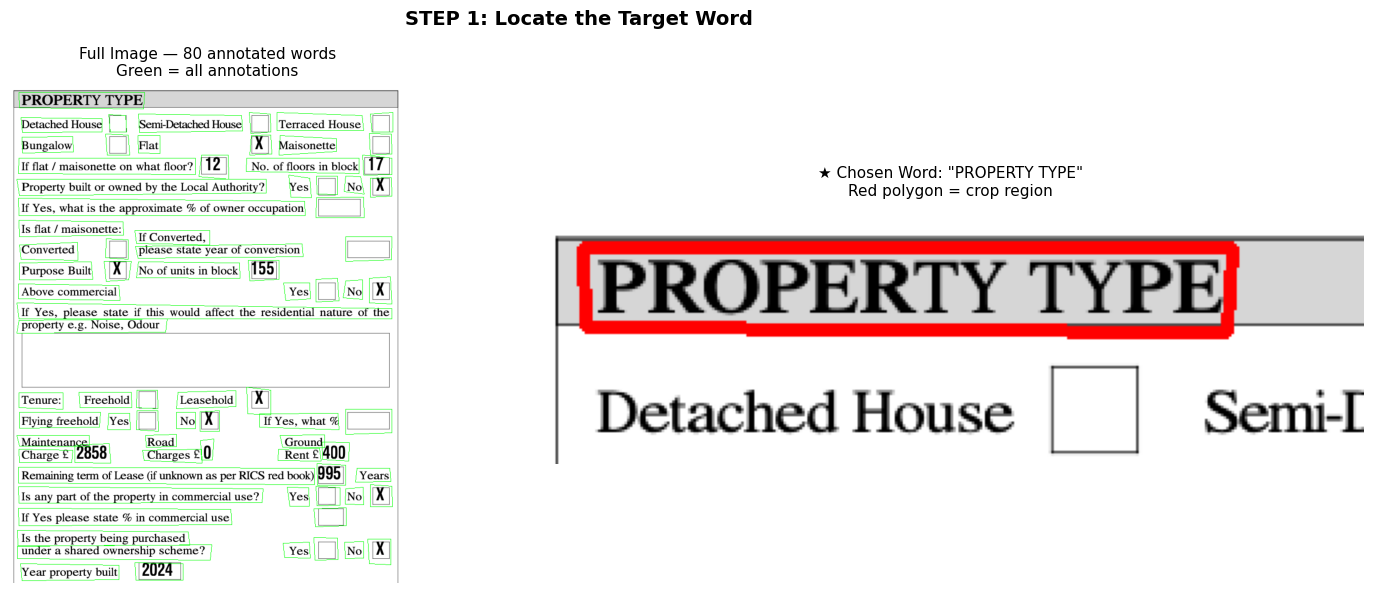

In [4]:

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/train-ocr-model')
MULTI_IMAGE_DIR = DATA_DIR / 'multiple_image_data'

json_path = MULTI_IMAGE_DIR / 'multiple_image.json'

with open(json_path, 'r') as f:
    all_annotations = json.load(f)

# Use the FIRST image, pick a word with decent length (not too short/long)
entry = all_annotations[0]

image_filename = entry.get('file_upload', '')
image_path = MULTI_IMAGE_DIR / image_filename

# Load image
original_image = cv2.imread(str(image_path))
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
H, W = original_image.shape[:2]

# Parse annotations — pair polygons with their text
results = entry['annotations'][0]['result']
orig_w = results[0]['original_width']
orig_h = results[0]['original_height']

poly_results = {}
text_results = {}

for r in results:
    rid = r['id']
    if r['type'] == 'polygon':
        points_pct = r['value']['points']
        pixel_points = []
        for px, py in points_pct:
            pixel_points.append([px * orig_w / 100.0, py * orig_h / 100.0])
        poly_results[rid] = np.array(pixel_points, dtype=np.float32)
    elif r['type'] == 'textarea':
        text_results[rid] = r['value']['text'][0] if r['value']['text'] else ''

# Build word list
all_words = []
for rid, poly in poly_results.items():
    text = text_results.get(rid, '')
    if text and len(text.strip()) >= 3 and len(text.strip()) <= 20:
        all_words.append({'polygon': poly, 'text': text.strip(), 'id': rid})

# Pick the best word — prefer something with both letters and digits if available
chosen = None
for w in all_words:
    if any(c.isdigit() for c in w['text']) and any(c.isalpha() for c in w['text']):
        chosen = w
        break
if chosen is None:
    chosen = all_words[0]  # fallback to first word

TARGET_TEXT = chosen['text']
TARGET_POLYGON = chosen['polygon']

print(f"{'='*60}")
print(f"SINGLE WORD DEEP DIVE")
print(f"{'='*60}")
print(f"  Image: {image_filename}")
print(f"  Image size: {W}×{H}")
print(f"  Total words in image: {len(poly_results)}")
print(f"  Words with length 3-20: {len(all_words)}")
print(f"")
print(f"  ★ CHOSEN WORD: \"{TARGET_TEXT}\"")
print(f"    Length: {len(TARGET_TEXT)} characters")
print(f"    Polygon: {TARGET_POLYGON.shape}")
print(f"{'='*60}")

# Show the word location on the image
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full image with all annotations
vis_all = original_image.copy()
for rid, poly in poly_results.items():
    pts = poly.astype(np.int32)
    cv2.polylines(vis_all, [pts], True, (0, 255, 0), 1)

axes[0].imshow(vis_all)
axes[0].set_title(f'Full Image — {len(poly_results)} annotated words\nGreen = all annotations', fontsize=11)
axes[0].axis('off')

# Zoomed in on chosen word
vis_zoom = original_image.copy()
pts = TARGET_POLYGON.astype(np.int32)
cv2.polylines(vis_zoom, [pts], True, (255, 0, 0), 3)

# Get bounding region for zoom
x_min = max(0, int(pts[:, 0].min()) - 50)
x_max = min(W, int(pts[:, 0].max()) + 50)
y_min = max(0, int(pts[:, 1].min()) - 50)
y_max = min(H, int(pts[:, 1].max()) + 50)

axes[1].imshow(vis_zoom[y_min:y_max, x_min:x_max])
axes[1].set_title(f'★ Chosen Word: "{TARGET_TEXT}"\nRed polygon = crop region', fontsize=11)
axes[1].axis('off')

plt.suptitle('STEP 1: Locate the Target Word', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


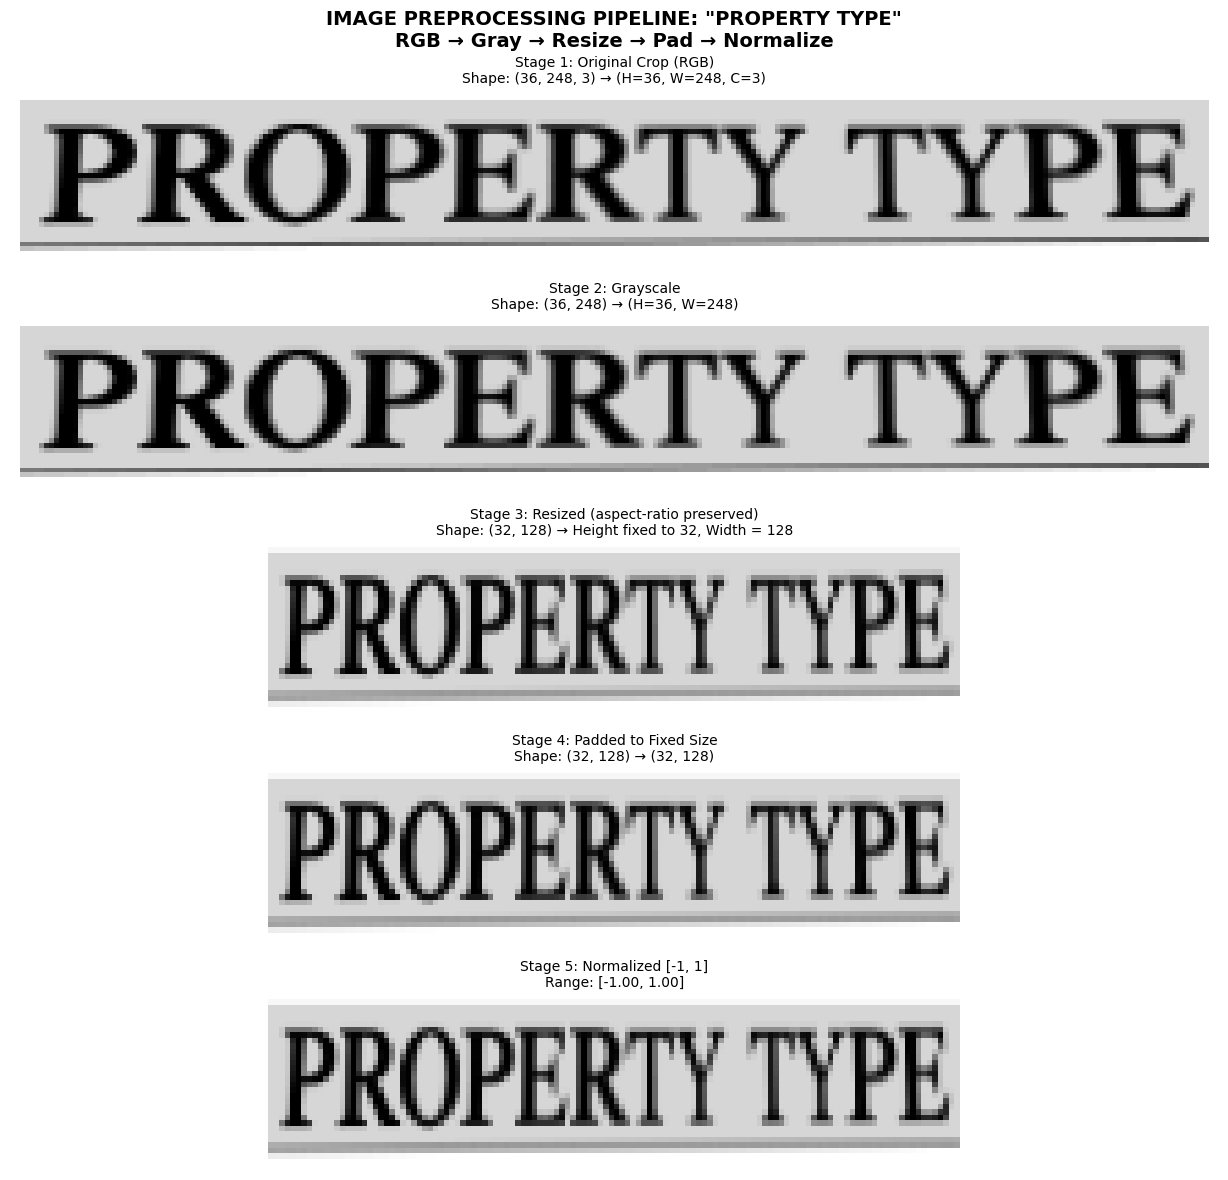


✓ Word tensor ready: torch.Size([1, 1, 32, 128])
  Target text: "PROPERTY TYPE"


In [5]:

def order_points(pts):
    """Order points: top-left, top-right, bottom-right, bottom-left."""
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect


def crop_and_warp(image, polygon, padding=2):
    """Crop text region using perspective transform."""
    # Handle polygons with more than 4 points — use bounding rect
    if len(polygon) != 4:
        rect = cv2.minAreaRect(polygon.astype(np.float32))
        box = cv2.boxPoints(rect)
        polygon = box

    pts = order_points(polygon.astype(np.float32))

    width_top = np.linalg.norm(pts[1] - pts[0])
    width_bottom = np.linalg.norm(pts[2] - pts[3])
    width = int(max(width_top, width_bottom))

    height_left = np.linalg.norm(pts[3] - pts[0])
    height_right = np.linalg.norm(pts[2] - pts[1])
    height = int(max(height_left, height_right))

    if width < 5 or height < 5:
        return None

    dst = np.array([
        [0, 0], [width - 1, 0],
        [width - 1, height - 1], [0, height - 1]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(pts, dst)
    warped = cv2.warpPerspective(image, M, (width, height))

    if padding > 0:
        warped = cv2.copyMakeBorder(warped, padding, padding, padding, padding,
                                     cv2.BORDER_CONSTANT, value=(255, 255, 255))
    return warped


# Crop the word
cropped_rgb = crop_and_warp(original_image, TARGET_POLYGON)
assert cropped_rgb is not None, "Failed to crop word!"

# Processing pipeline stages
stage1_original = cropped_rgb.copy()
stage2_gray = cv2.cvtColor(cropped_rgb, cv2.COLOR_RGB2GRAY)

# Resize preserving aspect ratio
h, w = stage2_gray.shape
ratio = IMG_HEIGHT / h
new_w = min(int(w * ratio), IMG_WIDTH)
stage3_resized = cv2.resize(stage2_gray, (new_w, IMG_HEIGHT))

# Pad to fixed width
stage4_padded = stage3_resized.copy()
if new_w < IMG_WIDTH:
    stage4_padded = np.pad(stage4_padded,
                           ((0, 0), (0, IMG_WIDTH - new_w)),
                           mode='constant', constant_values=0)

# Normalize
stage5_normalized = stage4_padded.astype(np.float32) / 255.0
stage5_normalized = (stage5_normalized - 0.5) / 0.5

# Show all stages
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

axes[0].imshow(stage1_original)
axes[0].set_title(f'Stage 1: Original Crop (RGB)\n'
                  f'Shape: {stage1_original.shape} → (H={stage1_original.shape[0]}, W={stage1_original.shape[1]}, C=3)',
                  fontsize=10)

axes[1].imshow(stage2_gray, cmap='gray')
axes[1].set_title(f'Stage 2: Grayscale\n'
                  f'Shape: {stage2_gray.shape} → (H={stage2_gray.shape[0]}, W={stage2_gray.shape[1]})',
                  fontsize=10)

axes[2].imshow(stage3_resized, cmap='gray')
axes[2].set_title(f'Stage 3: Resized (aspect-ratio preserved)\n'
                  f'Shape: {stage3_resized.shape} → Height fixed to {IMG_HEIGHT}, Width = {new_w}',
                  fontsize=10)

axes[3].imshow(stage4_padded, cmap='gray')
axes[3].set_title(f'Stage 4: Padded to Fixed Size\n'
                  f'Shape: {stage4_padded.shape} → ({IMG_HEIGHT}, {IMG_WIDTH})',
                  fontsize=10)

axes[4].imshow(stage5_normalized, cmap='gray')
axes[4].set_title(f'Stage 5: Normalized [-1, 1]\n'
                  f'Range: [{stage5_normalized.min():.2f}, {stage5_normalized.max():.2f}]',
                  fontsize=10)

for ax in axes:
    ax.axis('off')

plt.suptitle(f'IMAGE PREPROCESSING PIPELINE: "{TARGET_TEXT}"\n'
             f'RGB → Gray → Resize → Pad → Normalize',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Create the final tensor
word_tensor = torch.from_numpy(stage5_normalized).unsqueeze(0).unsqueeze(0)  # (1, 1, 32, 128)
print(f"\n✓ Word tensor ready: {word_tensor.shape}")
print(f"  Target text: \"{TARGET_TEXT}\"")


CHARACTER SET & ENCODING
  Total classes: 97 (including blank)
  Characters: 0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMN...

  Target text:  "PROPERTY TYPE"
  Encoded:      [52, 54, 51, 52, 41, 54, 56, 61, 95, 56, 61, 52, 41]
  Decoded back: "PROPERTY TYPE"
  Match: ✓


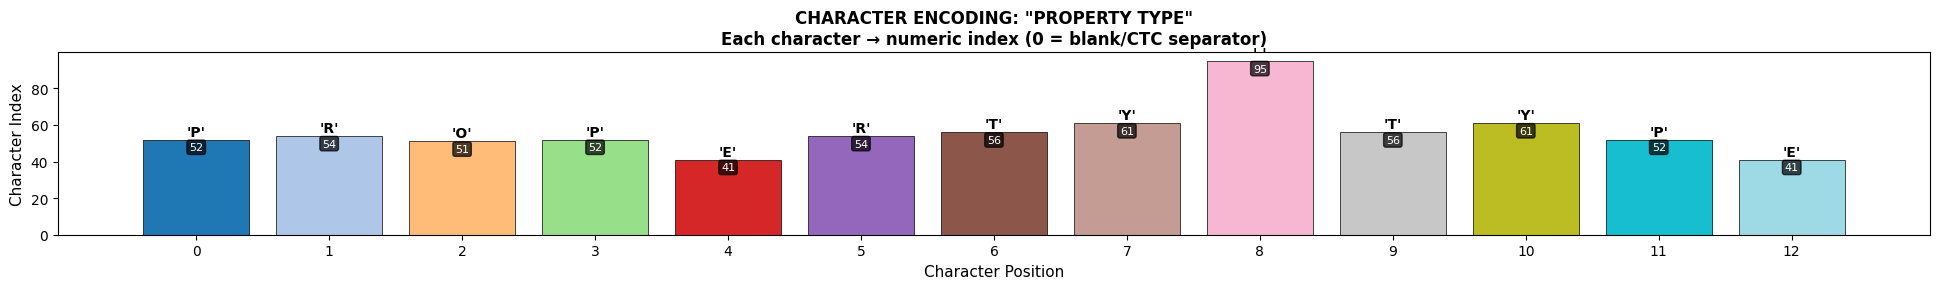

In [6]:

class CharacterSet:
    """Character set for text recognition."""

    def __init__(self):
        self.characters = string.digits + string.ascii_lowercase + string.ascii_uppercase
        self.characters += "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~ £"

        self.blank_token = '-'
        self.char_to_idx = {self.blank_token: 0}
        self.idx_to_char = {0: self.blank_token}

        for i, char in enumerate(self.characters):
            self.char_to_idx[char] = i + 1
            self.idx_to_char[i + 1] = char

        self.num_classes = len(self.characters) + 1  # +1 for blank

    def encode(self, text):
        return [self.char_to_idx.get(c, 0) for c in text]

    def decode(self, indices, remove_duplicates=True):
        chars = []
        prev_idx = None
        for idx in indices:
            if idx == 0:  # blank
                prev_idx = idx
                continue
            if remove_duplicates and idx == prev_idx:
                continue
            chars.append(self.idx_to_char.get(idx, ''))
            prev_idx = idx
        return ''.join(chars)


charset = CharacterSet()

# Show encoding for our target word
encoded = charset.encode(TARGET_TEXT)
decoded = charset.decode(encoded, remove_duplicates=False)

print(f"{'='*60}")
print(f"CHARACTER SET & ENCODING")
print(f"{'='*60}")
print(f"  Total classes: {charset.num_classes} (including blank)")
print(f"  Characters: {charset.characters[:50]}...")
print(f"")
print(f"  Target text:  \"{TARGET_TEXT}\"")
print(f"  Encoded:      {encoded}")
print(f"  Decoded back: \"{decoded}\"")
print(f"  Match: {'✓' if decoded == TARGET_TEXT else '✗'}")

# Visualize the encoding
fig, ax = plt.subplots(figsize=(max(12, len(TARGET_TEXT) * 1.5), 3))
colors = plt.cm.tab20(np.linspace(0, 1, len(encoded)))

bars = ax.bar(range(len(encoded)), encoded, color=colors, edgecolor='black', linewidth=0.5)
for i, (char, idx) in enumerate(zip(TARGET_TEXT, encoded)):
    ax.text(i, idx + 0.5, f"'{char}'", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(i, idx - 1.5, str(idx), ha='center', va='top', fontsize=8, color='white',
            bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2'))

ax.set_xlabel('Character Position', fontsize=11)
ax.set_ylabel('Character Index', fontsize=11)
ax.set_title(f'CHARACTER ENCODING: "{TARGET_TEXT}"\n'
             f'Each character → numeric index (0 = blank/CTC separator)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(encoded)))
plt.tight_layout()
plt.show()


In [7]:

class CRNN(nn.Module):
    """CRNN: CNN + BiLSTM + CTC for text recognition."""

    def __init__(self, num_classes, img_height=32, hidden_size=256):
        super().__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # Block 1: 1→64, /2
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 2: 64→128, /2
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 3: 128→256
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            # Block 4: 256→256, /2 height only
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2, 1), (2, 1)),
            # Block 5: 256→512
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            # Block 6: 512→512, /2 height only
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2, 1), (2, 1)),
            # Block 7: 512→512
            nn.Conv2d(512, 512, 2), nn.BatchNorm2d(512), nn.ReLU()
        )

        # BiLSTM
        self.rnn = nn.LSTM(512, hidden_size, bidirectional=True, batch_first=True)

        # Output projection
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn(x)           # (B, 512, 1, W')
        b, c, h, w = conv.size()
        conv = conv.squeeze(2)       # (B, 512, W')
        conv = conv.permute(0, 2, 1) # (B, W', 512)
        rnn_out, _ = self.rnn(conv)  # (B, W', 512)
        output = self.fc(rnn_out)    # (B, W', num_classes)
        return output


model = CRNN(num_classes=charset.num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"{'='*60}")
print(f"CRNN MODEL ARCHITECTURE")
print(f"{'='*60}")
print(f"  Total parameters: {total_params:,}")
print(f"  Num classes: {charset.num_classes}")

# Trace tensor dimensions through the model
print(f"\n{'='*60}")
print(f"TENSOR SHAPE TRACE")
print(f"{'='*60}")

x = word_tensor.to(device)
print(f"  Input:           {x.shape}  →  (batch=1, C=1, H={IMG_HEIGHT}, W={IMG_WIDTH})")

# Trace through CNN blocks manually
cnn_layers = list(model.cnn.children())
layer_names = [
    'Conv2d(1→64)', 'ReLU', 'MaxPool2d(2×2)',
    'Conv2d(64→128)', 'ReLU', 'MaxPool2d(2×2)',
    'Conv2d(128→256)', 'BatchNorm2d', 'ReLU',
    'Conv2d(256→256)', 'ReLU', 'MaxPool2d(2×1)',
    'Conv2d(256→512)', 'BatchNorm2d', 'ReLU',
    'Conv2d(512→512)', 'ReLU', 'MaxPool2d(2×1)',
    'Conv2d(512→512, k=2)', 'BatchNorm2d', 'ReLU'
]

with torch.no_grad():
    out = x
    for i, (layer, name) in enumerate(zip(cnn_layers, layer_names)):
        out = layer(out)
        if 'Pool' in name or 'Conv' in name:
            print(f"  {name:25s} → {list(out.shape)}")

    print(f"  {'Squeeze + Permute':25s} → [{out.shape[0]}, {out.shape[3]}, {out.shape[1]}]  (B, T={out.shape[3]}, C=512)")

    # Full forward
    full_output = model(x)
    print(f"  {'BiLSTM + Linear':25s} → {list(full_output.shape)}  (B, T={full_output.shape[1]}, Classes={full_output.shape[2]})")

T = full_output.shape[1]
print(f"\n  ★ CTC sequence length (T) = {T}")
print(f"  ★ This means the model outputs {T} predictions per input image")
print(f"  ★ Target text \"{TARGET_TEXT}\" has {len(TARGET_TEXT)} characters")
print(f"  ★ T ({T}) >= text_length ({len(TARGET_TEXT)}): {'✓ OK' if T >= len(TARGET_TEXT) else '✗ PROBLEM!'}")


CRNN MODEL ARCHITECTURE
  Total parameters: 7,178,081
  Num classes: 97

TENSOR SHAPE TRACE
  Input:           torch.Size([1, 1, 32, 128])  →  (batch=1, C=1, H=32, W=128)
  Conv2d(1→64)              → [1, 64, 32, 128]
  MaxPool2d(2×2)            → [1, 64, 16, 64]
  Conv2d(64→128)            → [1, 128, 16, 64]
  MaxPool2d(2×2)            → [1, 128, 8, 32]
  Conv2d(128→256)           → [1, 256, 8, 32]
  Conv2d(256→256)           → [1, 256, 8, 32]
  MaxPool2d(2×1)            → [1, 256, 4, 32]
  Conv2d(256→512)           → [1, 512, 4, 32]
  Conv2d(512→512)           → [1, 512, 4, 32]
  MaxPool2d(2×1)            → [1, 512, 2, 32]
  Conv2d(512→512, k=2)      → [1, 512, 1, 31]
  Squeeze + Permute         → [1, 31, 512]  (B, T=31, C=512)
  BiLSTM + Linear           → [1, 31, 97]  (B, T=31, Classes=97)

  ★ CTC sequence length (T) = 31
  ★ This means the model outputs 31 predictions per input image
  ★ Target text "PROPERTY TYPE" has 13 characters
  ★ T (31) >= text_length (13): ✓ OK


In [8]:

# Reset model
torch.manual_seed(SEED)
model = CRNN(num_classes=charset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

NUM_EPOCHS = 200

# Prepare fixed input
input_tensor = word_tensor.to(device)   # (1, 1, 32, 128)

# Prepare CTC targets
target_encoded = torch.tensor(charset.encode(TARGET_TEXT), dtype=torch.long).to(device)
target_length = torch.tensor([len(TARGET_TEXT)], dtype=torch.long).to(device)

losses = []
decoded_texts = {}  # epoch -> decoded text
snapshot_epochs = [1, 5, 10, 25, 50, 75, 100, 150, 200]
ctc_snapshots = {}  # epoch -> raw CTC output

print(f"{'='*60}")
print(f"TRAINING: Overfit on \"{TARGET_TEXT}\"")
print(f"{'='*60}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Target: \"{TARGET_TEXT}\" ({len(TARGET_TEXT)} chars)")
print(f"  Optimizer: Adam, lr=0.001")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    model.train()

    # Forward
    output = model(input_tensor)  # (1, T, num_classes)
    log_probs = F.log_softmax(output, dim=2).permute(1, 0, 2)  # (T, 1, num_classes)

    input_length = torch.tensor([log_probs.size(0)], dtype=torch.long).to(device)

    loss = criterion(log_probs, target_encoded.unsqueeze(0), input_length, target_length)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
    optimizer.step()

    losses.append(loss.item())

    # Decode prediction
    model.eval()
    with torch.no_grad():
        pred_output = model(input_tensor)
        _, max_indices = pred_output.max(dim=2)
        pred_text = charset.decode(max_indices[0].cpu().numpy())

    if epoch + 1 in snapshot_epochs:
        decoded_texts[epoch + 1] = pred_text
        ctc_snapshots[epoch + 1] = pred_output[0].cpu().numpy()  # (T, num_classes)

        match = "✓" if pred_text == TARGET_TEXT else "✗"
        print(f"  Epoch {epoch+1:3d}: Loss={loss.item():.6f} | "
              f"Pred=\"{pred_text}\" {match}")

# Also save every-epoch decoded text for the timeline
all_decoded = []
model.eval()
# Re-run to get final
with torch.no_grad():
    final_output = model(input_tensor)
    _, max_indices = final_output.max(dim=2)
    final_pred = charset.decode(max_indices[0].cpu().numpy())

print(f"\n{'='*60}")
print(f"  FINAL: Loss={losses[-1]:.6f}")
print(f"  GT:   \"{TARGET_TEXT}\"")
print(f"  Pred: \"{final_pred}\"")
print(f"  Match: {'✓ PERFECT' if final_pred == TARGET_TEXT else '✗ MISMATCH'}")
print(f"{'='*60}")

TRAINING: Overfit on "PROPERTY TYPE"
  Epochs: 200
  Target: "PROPERTY TYPE" (13 chars)
  Optimizer: Adam, lr=0.001

  Epoch   1: Loss=8.930329 | Pred="1P1P1" ✗
  Epoch   5: Loss=2.505264 | Pred="" ✗
  Epoch  10: Loss=1.153851 | Pred="TY" ✗
  Epoch  25: Loss=0.207751 | Pred="PYTYTY Y" ✗
  Epoch  50: Loss=0.008557 | Pred="PROPERTY TYPE" ✓
  Epoch  75: Loss=0.003581 | Pred="PROPERTY TYPE" ✓
  Epoch 100: Loss=0.002432 | Pred="PROPERTY TYPE" ✓
  Epoch 150: Loss=0.001478 | Pred="PROPERTY TYPE" ✓
  Epoch 200: Loss=0.001028 | Pred="PROPERTY TYPE" ✓

  FINAL: Loss=0.001028
  GT:   "PROPERTY TYPE"
  Pred: "PROPERTY TYPE"
  Match: ✓ PERFECT


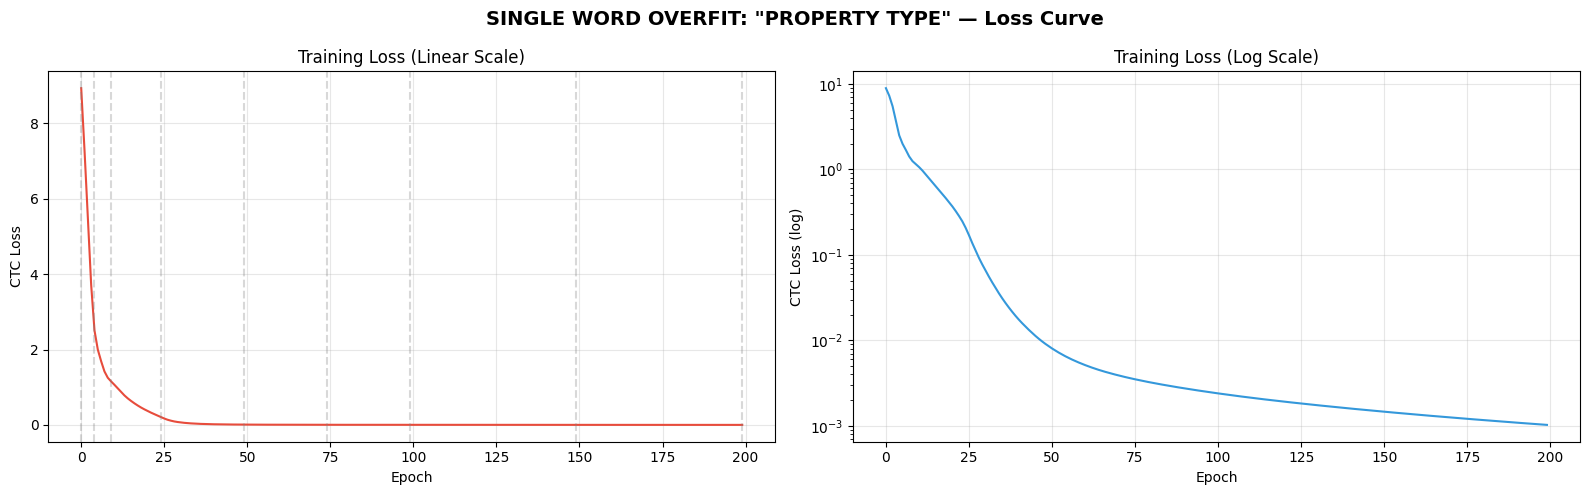

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(losses, color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].set_title('Training Loss (Linear Scale)')
axes[0].grid(True, alpha=0.3)

# Mark snapshot epochs
for ep in snapshot_epochs:
    if ep <= len(losses):
        axes[0].axvline(ep - 1, color='gray', alpha=0.3, linestyle='--')

axes[1].plot(losses, color='#3498db', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CTC Loss (log)')
axes[1].set_title('Training Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'SINGLE WORD OVERFIT: "{TARGET_TEXT}" — Loss Curve',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


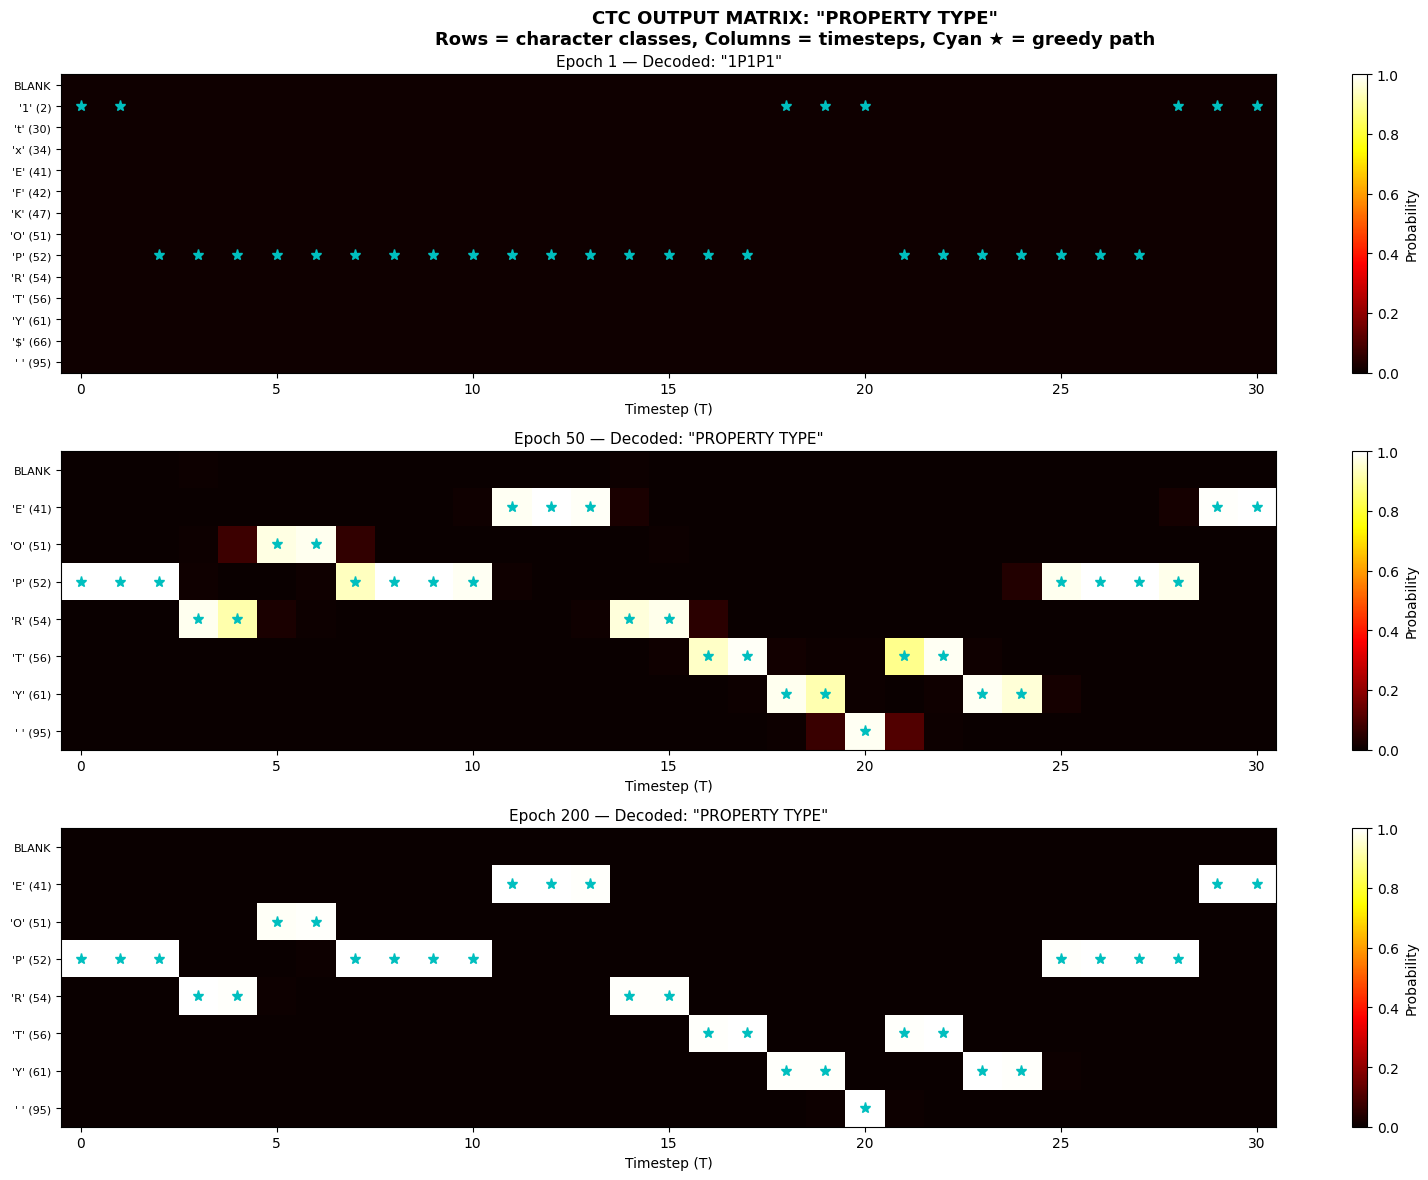

In [10]:

# Show the CTC output matrix at a few key epochs
epochs_to_show = [1, 50, 200]
epochs_to_show = [e for e in epochs_to_show if e in ctc_snapshots]

fig, axes = plt.subplots(len(epochs_to_show), 1,
                         figsize=(16, 4 * len(epochs_to_show)))
if len(epochs_to_show) == 1:
    axes = [axes]

for ax_idx, ep in enumerate(epochs_to_show):
    ctc_out = ctc_snapshots[ep]  # (T, num_classes)
    probs = np.exp(ctc_out - ctc_out.max(axis=1, keepdims=True))
    probs = probs / probs.sum(axis=1, keepdims=True)

    # Show only the top-N most active classes for clarity
    active_classes = np.unique(np.argsort(probs, axis=1)[:, -5:])
    # Always include blank (0) and target character indices
    target_indices = charset.encode(TARGET_TEXT)
    active_classes = np.unique(np.concatenate([active_classes, [0], target_indices]))
    active_classes = sorted(active_classes)

    sub_probs = probs[:, active_classes]
    class_labels = []
    for c in active_classes:
        if c == 0:
            class_labels.append('BLANK')
        else:
            char = charset.idx_to_char.get(c, '?')
            class_labels.append(f"'{char}' ({c})")

    im = axes[ax_idx].imshow(sub_probs.T, aspect='auto', cmap='hot',
                              vmin=0, vmax=1)
    axes[ax_idx].set_yticks(range(len(class_labels)))
    axes[ax_idx].set_yticklabels(class_labels, fontsize=8)
    axes[ax_idx].set_xlabel('Timestep (T)')
    axes[ax_idx].set_title(f'Epoch {ep} — Decoded: "{decoded_texts.get(ep, "?")}"',
                           fontsize=11)

    # Draw the greedy path
    greedy = np.argmax(probs, axis=1)
    for t in range(len(greedy)):
        if greedy[t] in active_classes:
            y_pos = list(active_classes).index(greedy[t])
            axes[ax_idx].plot(t, y_pos, 'c*', markersize=8)

    plt.colorbar(im, ax=axes[ax_idx], label='Probability')

plt.suptitle(f'CTC OUTPUT MATRIX: "{TARGET_TEXT}"\n'
             f'Rows = character classes, Columns = timesteps, Cyan ★ = greedy path',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


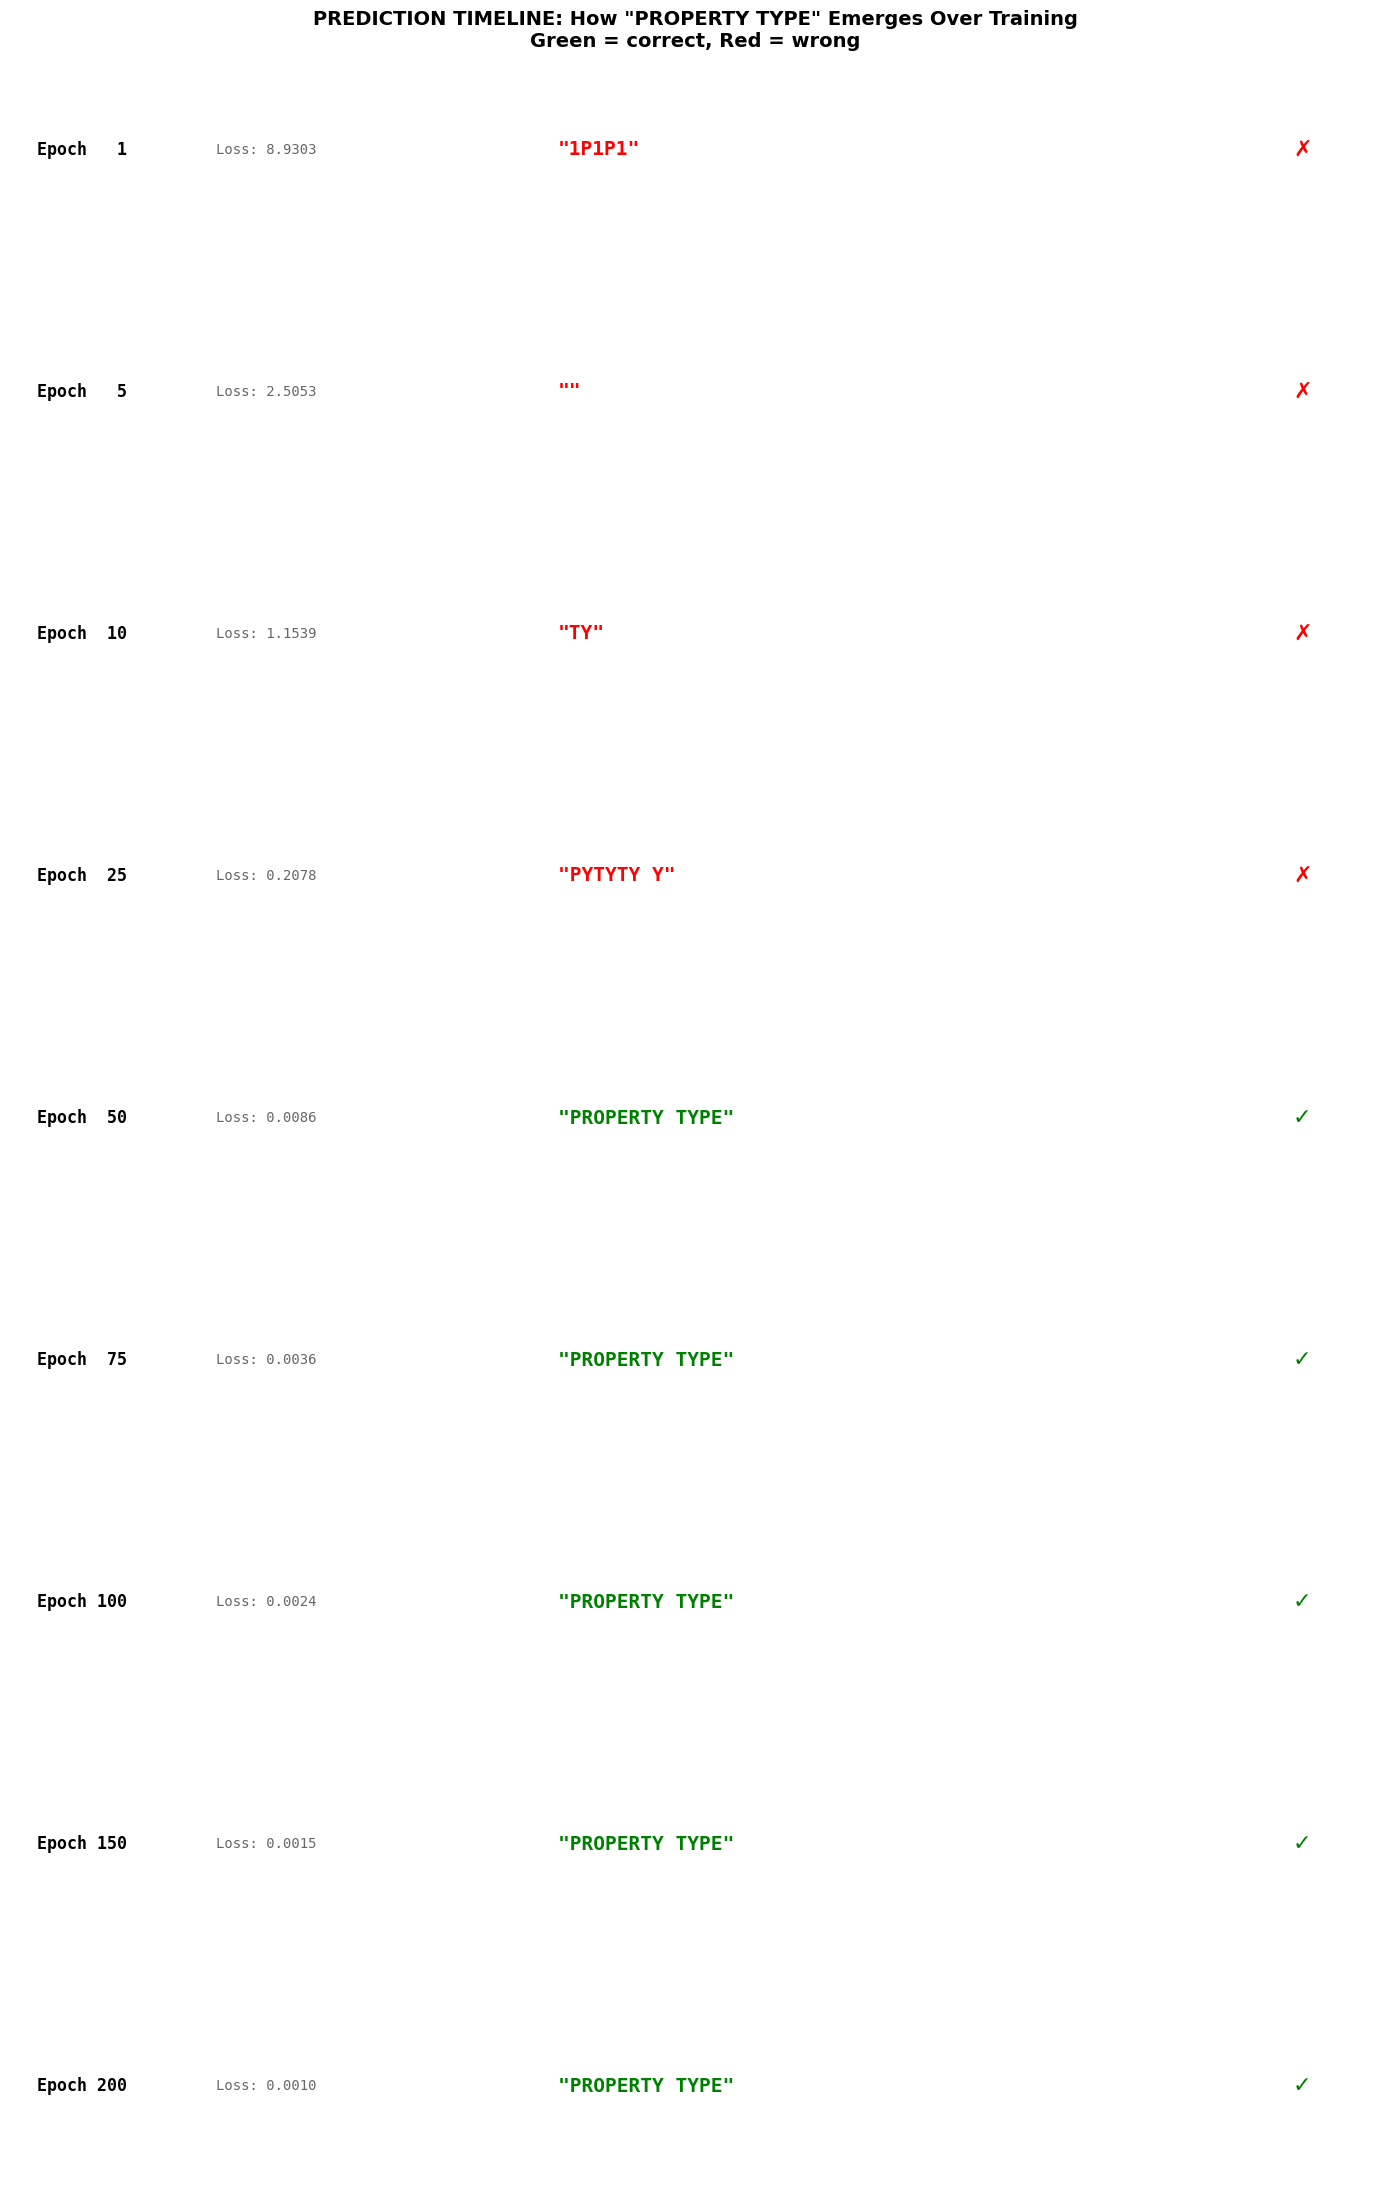

In [11]:

# Re-run model at each snapshot epoch to get the decoded progression
# (we already stored these in decoded_texts)

fig, axes = plt.subplots(len(snapshot_epochs), 1,
                         figsize=(14, 2.5 * len(snapshot_epochs)))

for ax_idx, ep in enumerate(snapshot_epochs):
    pred = decoded_texts.get(ep, '?')
    loss_at_ep = losses[ep - 1]

    ax = axes[ax_idx]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Background color based on match
    match = pred == TARGET_TEXT
    bg_color = '#d4edda' if match else '#f8d7da'
    ax.set_facecolor(bg_color)

    # Epoch info
    ax.text(0.02, 0.5, f'Epoch {ep:3d}', fontsize=12, fontweight='bold',
            va='center', family='monospace')

    # Loss
    ax.text(0.15, 0.5, f'Loss: {loss_at_ep:.4f}', fontsize=10,
            va='center', family='monospace', color='#666')

    # Predicted text (large)
    ax.text(0.40, 0.5, f'"{pred}"', fontsize=14, fontweight='bold',
            va='center', family='monospace',
            color='green' if match else 'red')

    # Match indicator
    symbol = '✓' if match else '✗'
    ax.text(0.95, 0.5, symbol, fontsize=16, fontweight='bold',
            va='center', ha='right',
            color='green' if match else 'red')

# Add GT reference at top
plt.suptitle(f'PREDICTION TIMELINE: How "{TARGET_TEXT}" Emerges Over Training\n'
             f'Green = correct, Red = wrong',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

FINAL COMPARISON

  Ground Truth: "PROPERTY TYPE"
  Prediction:   "PROPERTY TYPE"

  ★ PERFECT MATCH! The model successfully overfit on this word.


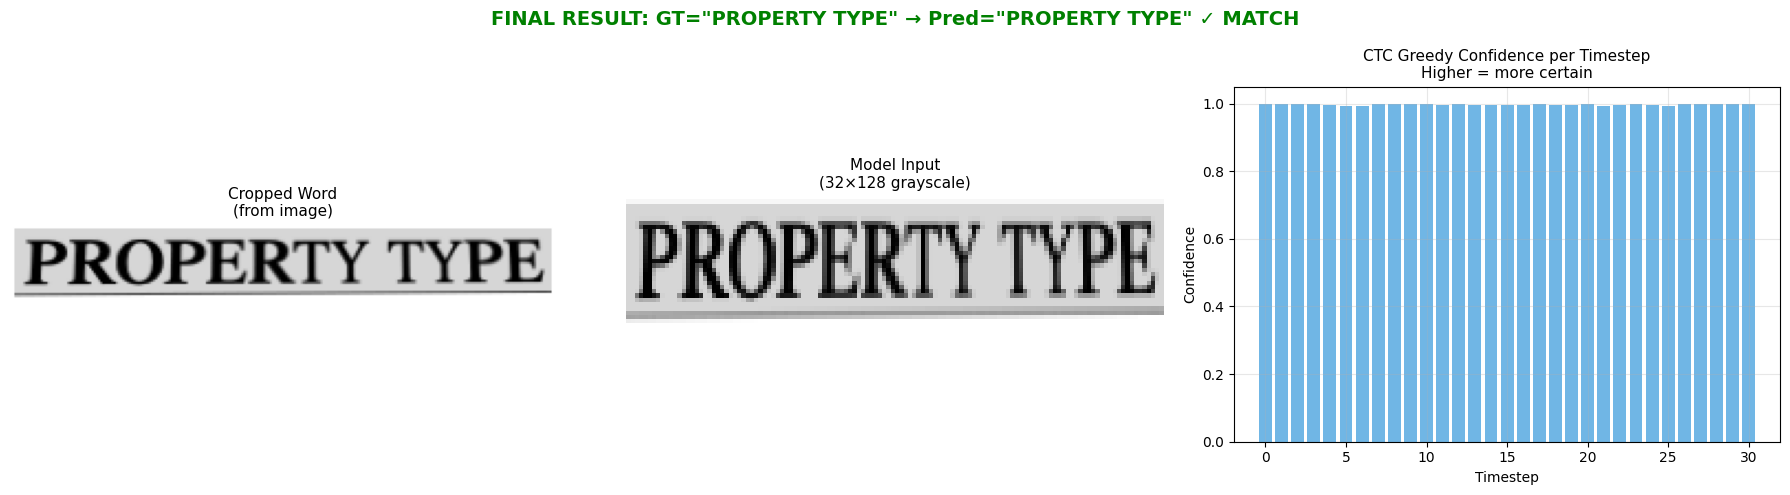


SUMMARY
  Word: "PROPERTY TYPE"
  Characters: 13
  Final loss: 0.001028
  Final prediction: "PROPERTY TYPE"
  Result: ✓ Successfully overfit!


In [12]:

print(f"{'='*60}")
print(f"FINAL COMPARISON")
print(f"{'='*60}")

# Character-by-character comparison
print(f"\n  Ground Truth: \"{TARGET_TEXT}\"")
print(f"  Prediction:   \"{final_pred}\"")
print()

if final_pred == TARGET_TEXT:
    print(f"  ★ PERFECT MATCH! The model successfully overfit on this word.")
else:
    # Character-level diff
    print(f"  Character-by-character:")
    max_len = max(len(TARGET_TEXT), len(final_pred))
    for i in range(max_len):
        gt_c = TARGET_TEXT[i] if i < len(TARGET_TEXT) else '∅'
        pr_c = final_pred[i] if i < len(final_pred) else '∅'
        match = '✓' if gt_c == pr_c else '✗'
        print(f"    [{i}] GT='{gt_c}' Pred='{pr_c}' {match}")

# Visualize final result
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cropped word
axes[0].imshow(stage1_original)
axes[0].set_title(f'Cropped Word\n(from image)', fontsize=11)
axes[0].axis('off')

# Processed input
axes[1].imshow(stage4_padded, cmap='gray')
axes[1].set_title(f'Model Input\n({IMG_HEIGHT}×{IMG_WIDTH} grayscale)', fontsize=11)
axes[1].axis('off')

# Final CTC output
final_ctc = ctc_snapshots[200]
final_probs = np.exp(final_ctc - final_ctc.max(axis=1, keepdims=True))
final_probs = final_probs / final_probs.sum(axis=1, keepdims=True)

greedy = np.argmax(final_probs, axis=1)
# Show probability of greedy choice at each timestep
greedy_probs = [final_probs[t, greedy[t]] for t in range(len(greedy))]

axes[2].bar(range(len(greedy_probs)), greedy_probs, color='#3498db', alpha=0.7)
axes[2].set_xlabel('Timestep')
axes[2].set_ylabel('Confidence')
axes[2].set_title(f'CTC Greedy Confidence per Timestep\n'
                  f'Higher = more certain', fontsize=11)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

match_str = '✓ MATCH' if final_pred == TARGET_TEXT else '✗ MISMATCH'
plt.suptitle(f'FINAL RESULT: GT="{TARGET_TEXT}" → Pred="{final_pred}" {match_str}',
             fontsize=14, fontweight='bold',
             color='green' if final_pred == TARGET_TEXT else 'red')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"  Word: \"{TARGET_TEXT}\"")
print(f"  Characters: {len(TARGET_TEXT)}")
print(f"  Final loss: {losses[-1]:.6f}")
print(f"  Final prediction: \"{final_pred}\"")
print(f"  Result: {'✓ Successfully overfit!' if final_pred == TARGET_TEXT else '✗ Did not converge'}")
print(f"{'='*60}")


CNN FEATURE MAP VISUALIZATION
  Passing "PROPERTY TYPE" through each CNN layer and
  visualizing what the network 'sees' at every stage.



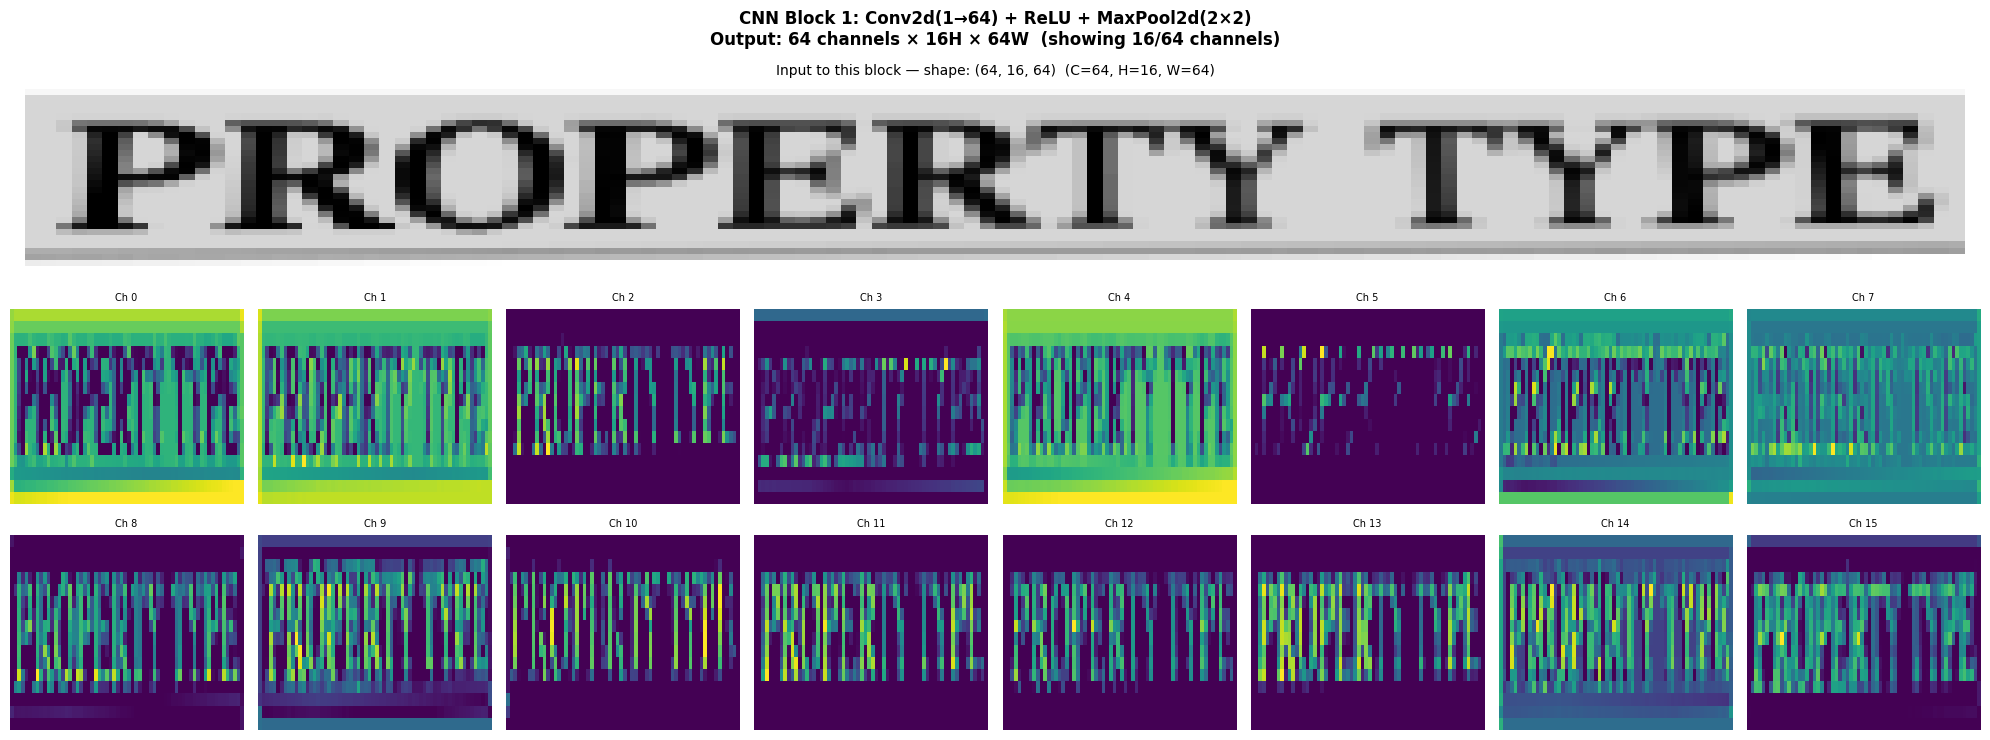

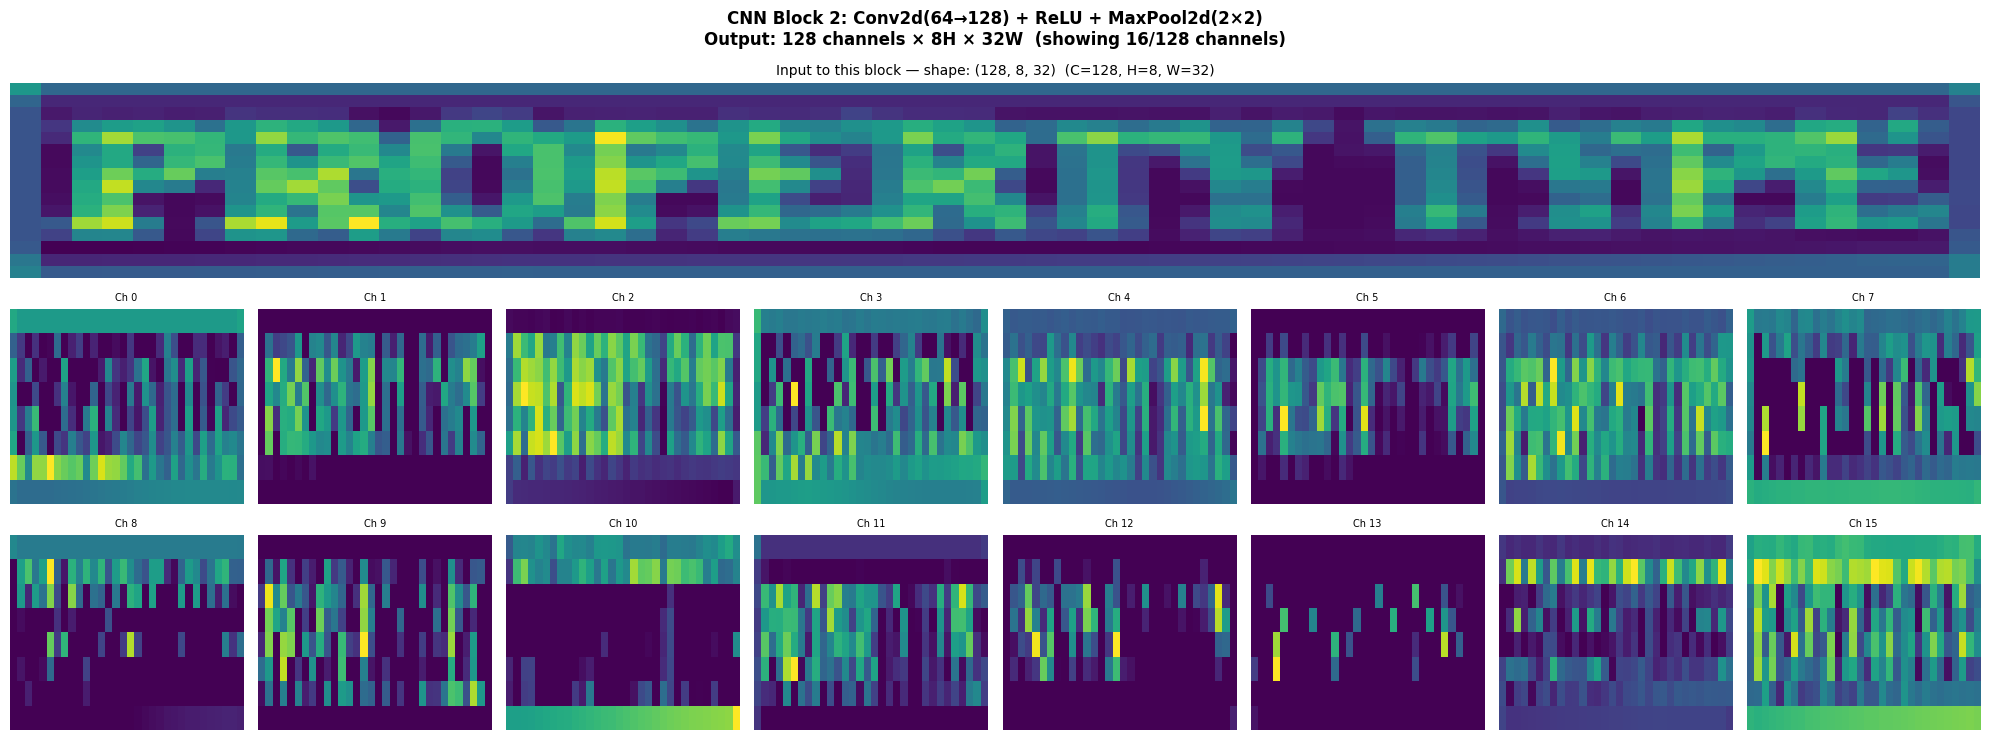

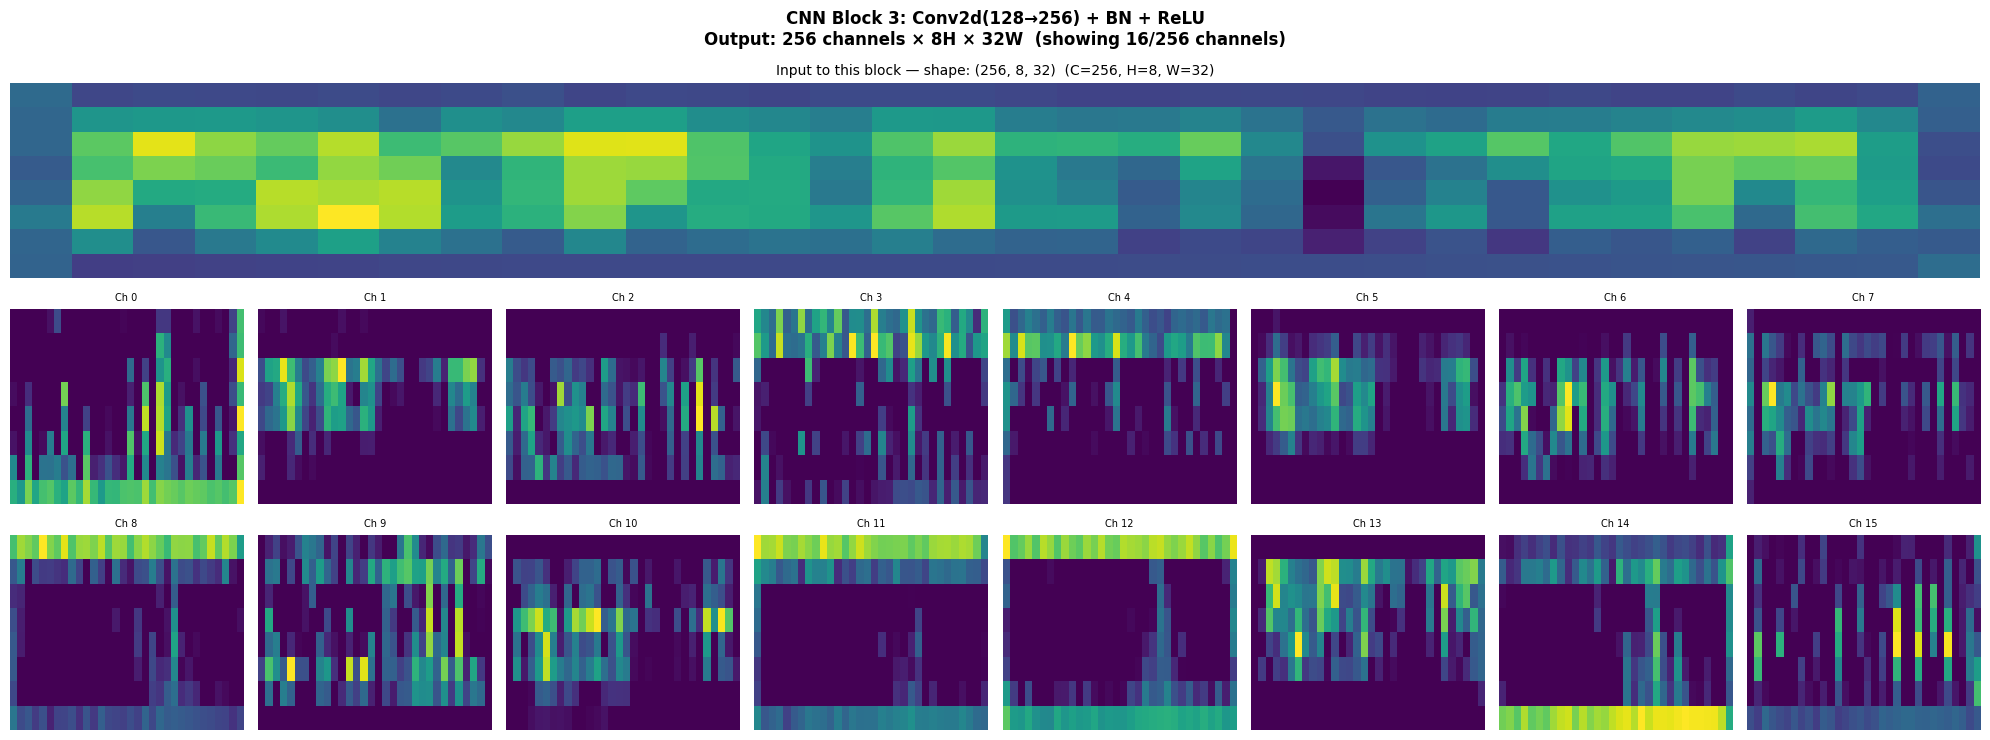

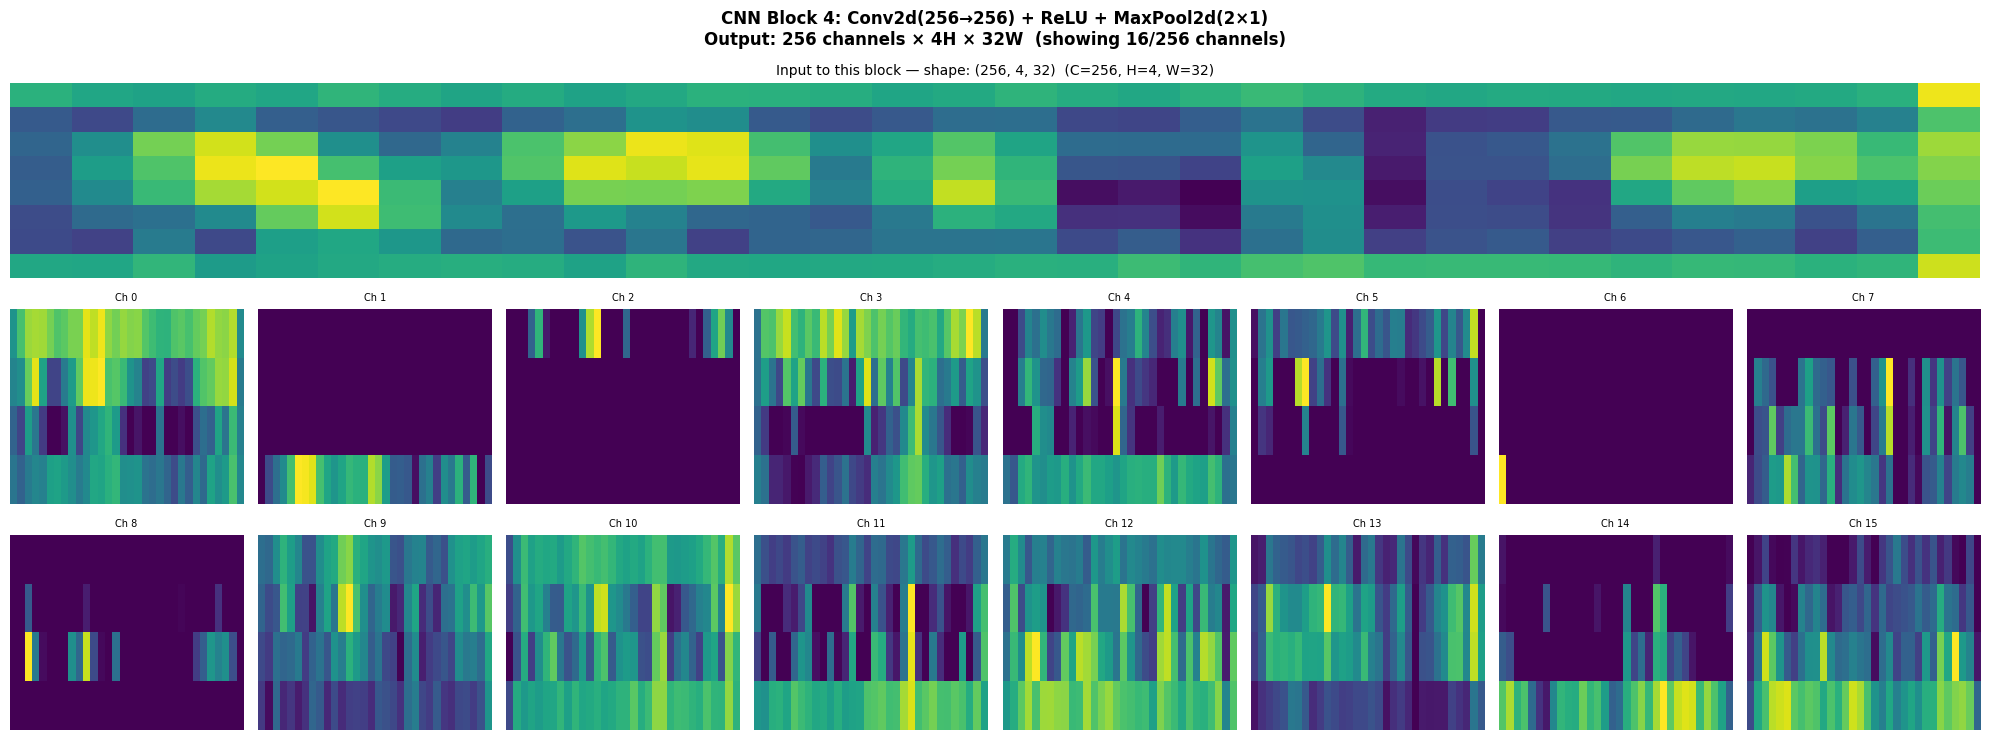

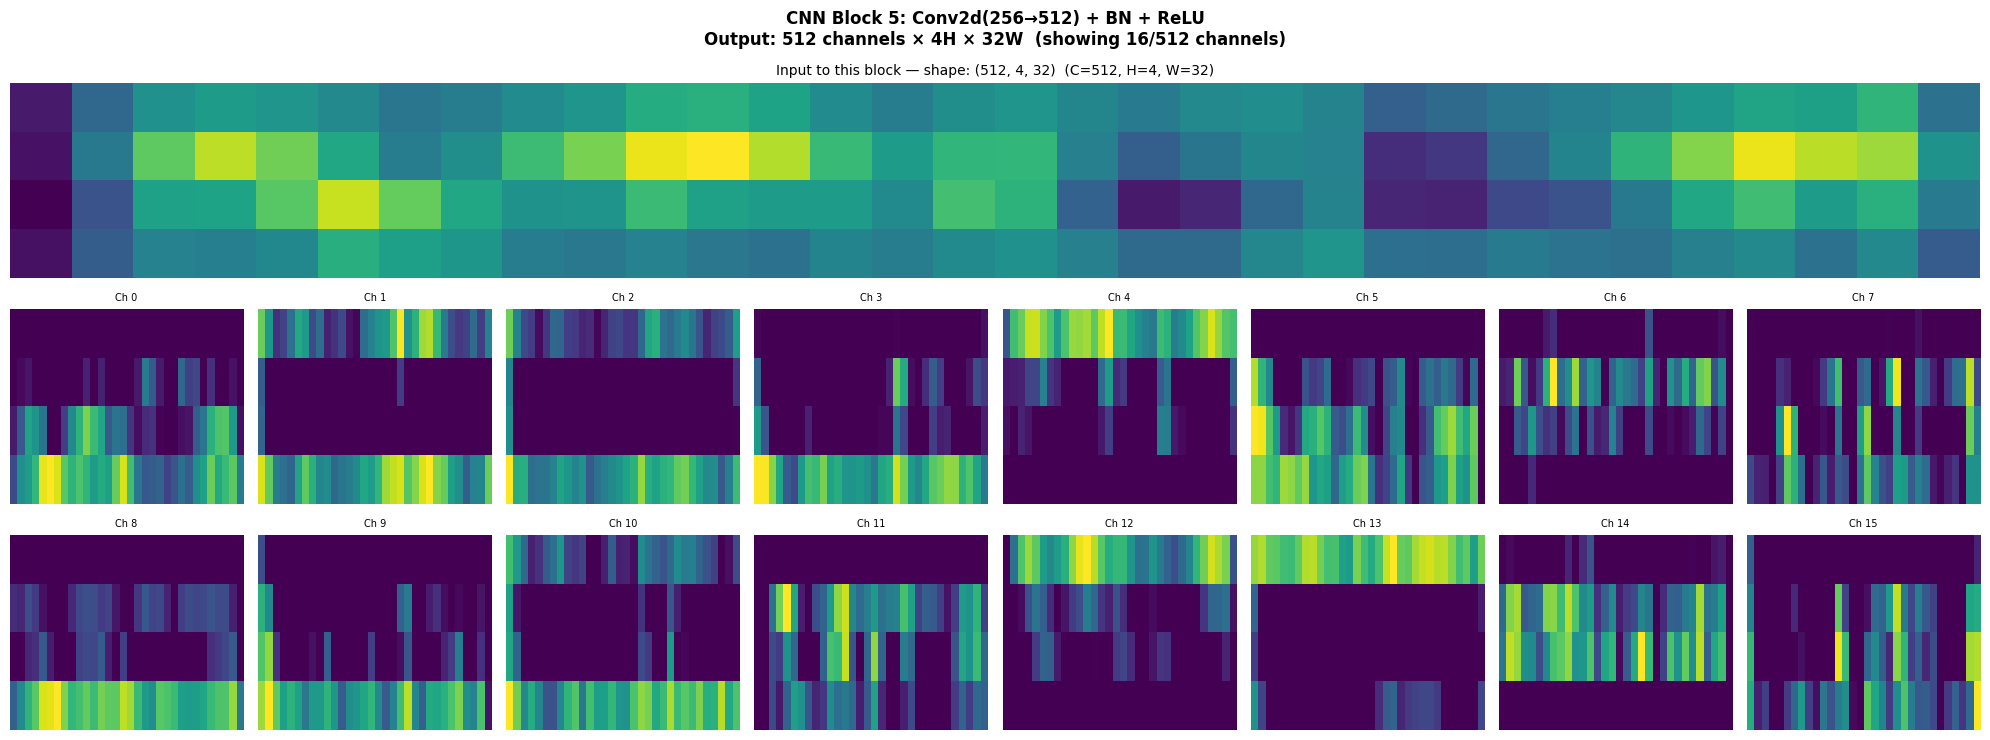

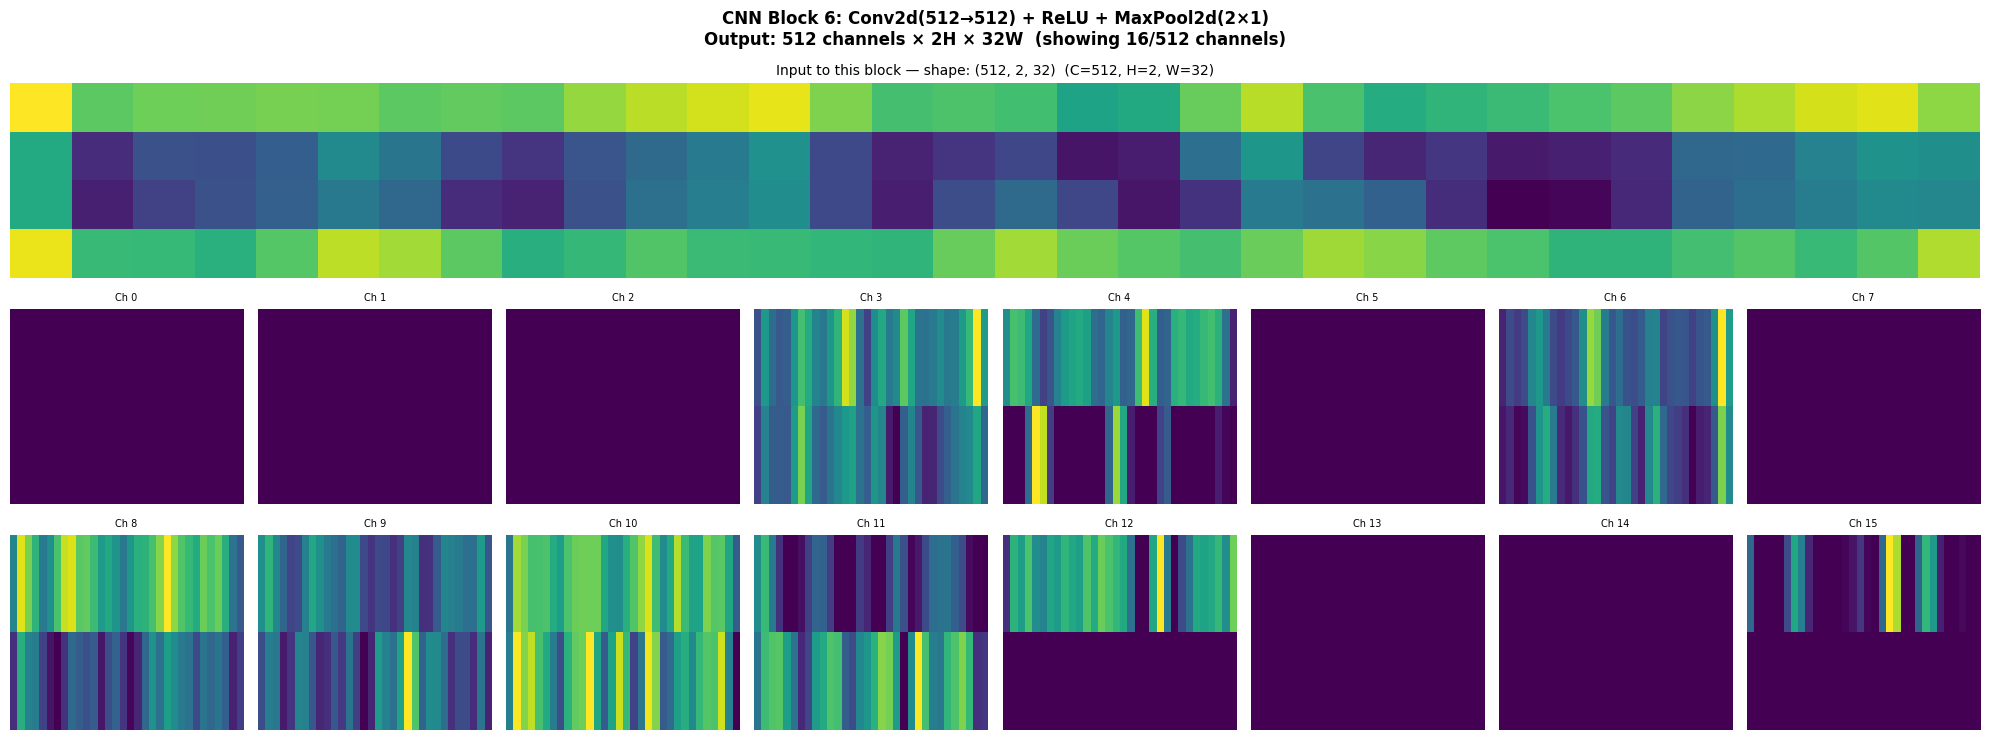

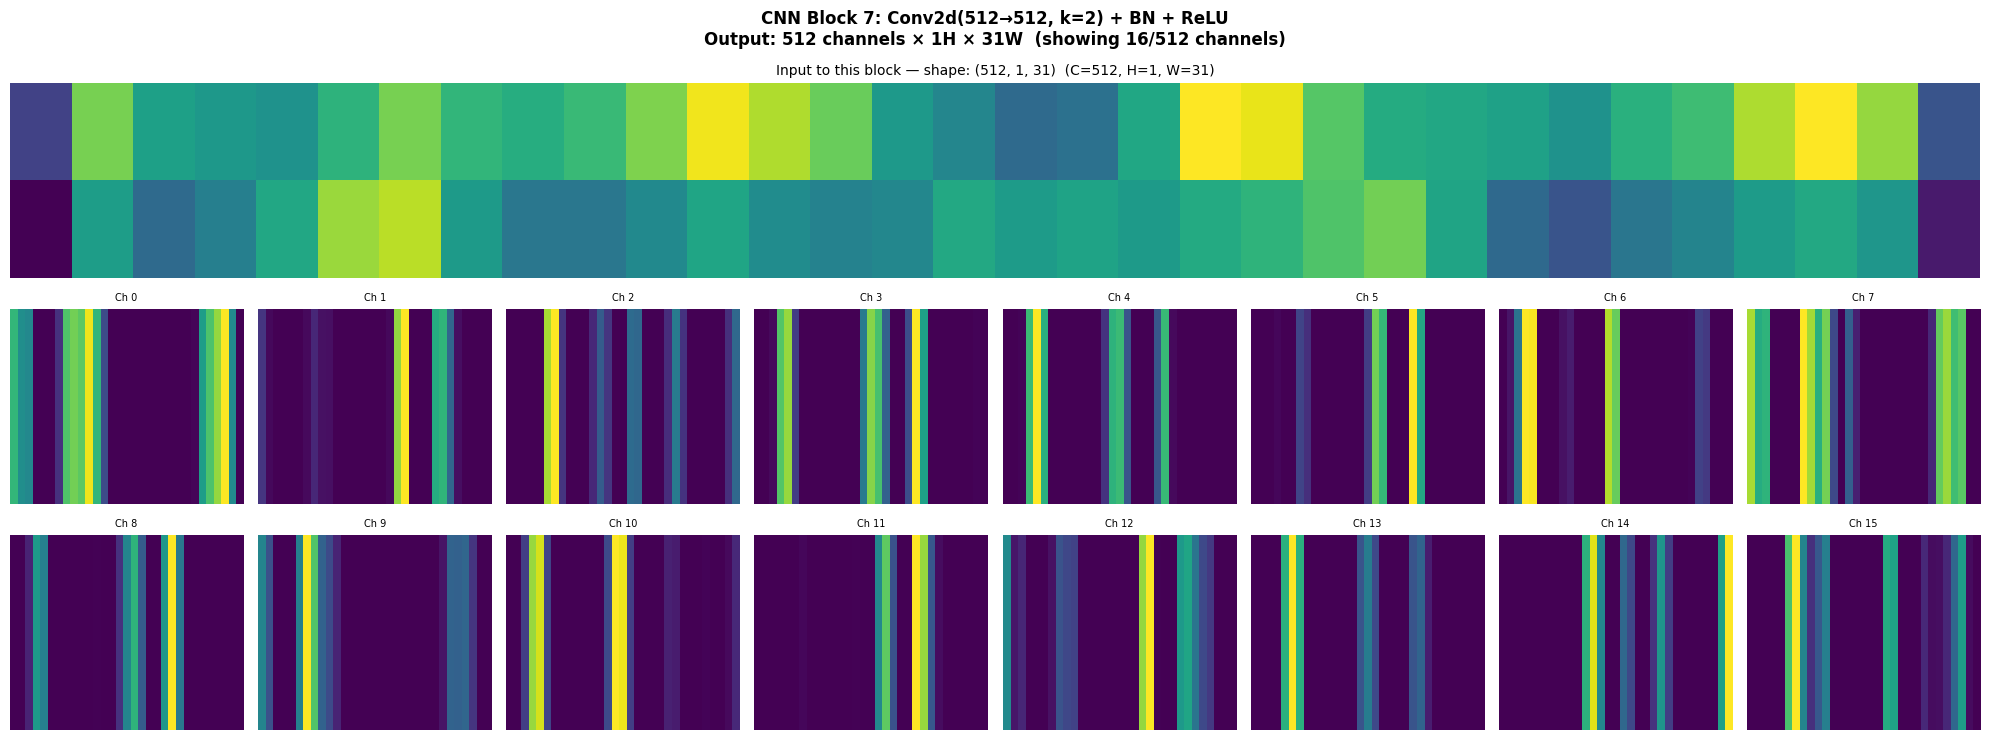

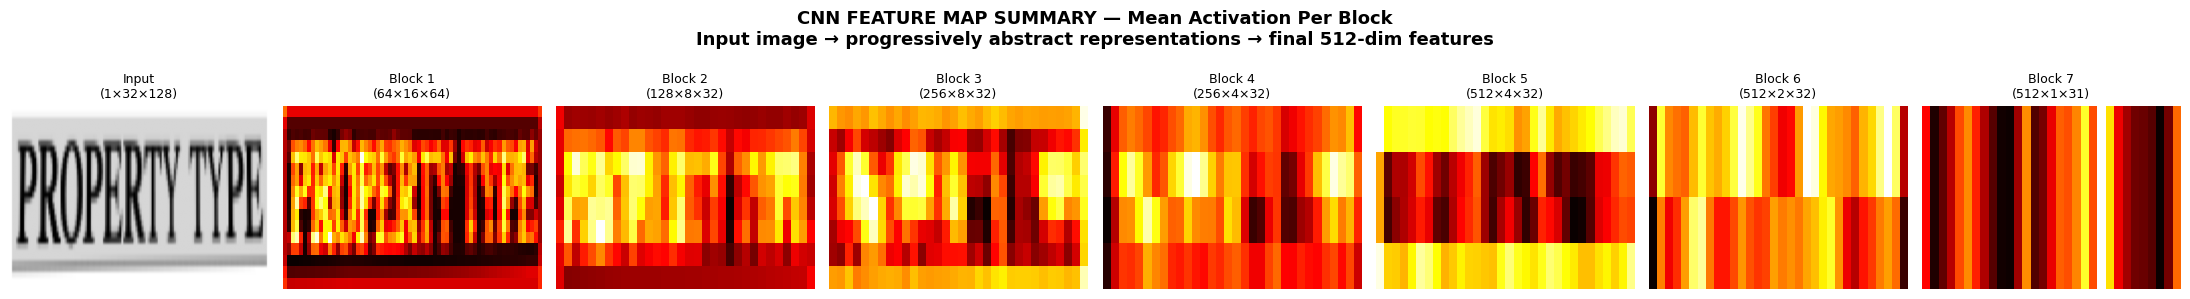


✓ Feature maps visualized for all 7 CNN blocks
  Early layers: detect edges, strokes, curves
  Middle layers: detect character parts, letter shapes
  Deep layers: detect full characters, word-level patterns


In [13]:

print(f"{'='*60}")
print(f"CNN FEATURE MAP VISUALIZATION")
print(f"{'='*60}")
print(f"  Passing \"{TARGET_TEXT}\" through each CNN layer and")
print(f"  visualizing what the network 'sees' at every stage.")
print(f"{'='*60}\n")

# Define the CNN blocks — group layers by conv block
cnn_block_info = [
    {'name': 'Block 1: Conv2d(1→64) + ReLU + MaxPool2d(2×2)',
     'layers': slice(0, 3), 'channels': 64},
    {'name': 'Block 2: Conv2d(64→128) + ReLU + MaxPool2d(2×2)',
     'layers': slice(3, 6), 'channels': 128},
    {'name': 'Block 3: Conv2d(128→256) + BN + ReLU',
     'layers': slice(6, 9), 'channels': 256},
    {'name': 'Block 4: Conv2d(256→256) + ReLU + MaxPool2d(2×1)',
     'layers': slice(9, 12), 'channels': 256},
    {'name': 'Block 5: Conv2d(256→512) + BN + ReLU',
     'layers': slice(12, 15), 'channels': 512},
    {'name': 'Block 6: Conv2d(512→512) + ReLU + MaxPool2d(2×1)',
     'layers': slice(15, 18), 'channels': 512},
    {'name': 'Block 7: Conv2d(512→512, k=2) + BN + ReLU',
     'layers': slice(18, 21), 'channels': 512},
]

# Extract feature maps from each block
model.eval()
cnn_layers = list(model.cnn.children())
feature_maps = []

with torch.no_grad():
    x = word_tensor.to(device)
    for block in cnn_block_info:
        for layer in cnn_layers[block['layers']]:
            x = layer(x)
        feature_maps.append(x.cpu().squeeze(0).numpy())  # (C, H, W)

# Visualize each block's feature maps
N_SHOW_CHANNELS = 16  # Show up to 16 channels per block

for block_idx, (block, fmap) in enumerate(zip(cnn_block_info, feature_maps)):
    n_channels = fmap.shape[0]
    n_show = min(N_SHOW_CHANNELS, n_channels)
    cols = 8
    rows = (n_show + cols - 1) // cols + 1  # +1 for input image row

    fig, axes = plt.subplots(rows, cols, figsize=(20, 2.5 * rows))
    axes_flat = axes.flatten()

    # Row 0: Show input image spanning first few columns
    for j in range(cols):
        axes[0][j].axis('off')

    # Merge first row into one axes for the input
    ax_input = fig.add_subplot(rows, 1, 1)
    if block_idx == 0:
        ax_input.imshow(stage5_normalized, cmap='gray', aspect='auto')
    else:
        # Show mean activation of previous block
        prev_mean = feature_maps[block_idx - 1].mean(axis=0)
        ax_input.imshow(prev_mean, cmap='viridis', aspect='auto')
    ax_input.set_title(f'Input to this block — shape: {fmap.shape}  (C={fmap.shape[0]}, H={fmap.shape[1]}, W={fmap.shape[2]})',
                       fontsize=10)
    ax_input.axis('off')

    # Remaining rows: individual channel feature maps
    for ch in range(n_show):
        ax = axes_flat[cols + ch]  # Skip first row
        channel_map = fmap[ch]
        ax.imshow(channel_map, cmap='viridis', aspect='auto')
        ax.set_title(f'Ch {ch}', fontsize=7)
        ax.axis('off')

    # Hide unused axes
    for j in range(cols + n_show, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'CNN {block["name"]}\n'
                 f'Output: {n_channels} channels × {fmap.shape[1]}H × {fmap.shape[2]}W  '
                 f'(showing {n_show}/{n_channels} channels)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Summary: Mean activation across all channels per block (one row)
fig, axes = plt.subplots(1, len(feature_maps) + 1, figsize=(22, 3))

# Original input
axes[0].imshow(stage5_normalized, cmap='gray', aspect='auto')
axes[0].set_title(f'Input\n(1×{IMG_HEIGHT}×{IMG_WIDTH})', fontsize=9)
axes[0].axis('off')

for i, (block, fmap) in enumerate(zip(cnn_block_info, feature_maps)):
    mean_map = fmap.mean(axis=0)
    axes[i + 1].imshow(mean_map, cmap='hot', aspect='auto')
    axes[i + 1].set_title(f'Block {i+1}\n({fmap.shape[0]}×{fmap.shape[1]}×{fmap.shape[2]})',
                          fontsize=9)
    axes[i + 1].axis('off')

plt.suptitle(f'CNN FEATURE MAP SUMMARY — Mean Activation Per Block\n'
             f'Input image → progressively abstract representations → final 512-dim features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Feature maps visualized for all 7 CNN blocks")
print(f"  Early layers: detect edges, strokes, curves")
print(f"  Middle layers: detect character parts, letter shapes")
print(f"  Deep layers: detect full characters, word-level patterns")
